In [45]:
import pandas as pd
import numpy as np


In [46]:
import zipfile

with zipfile.ZipFile("/content/combined_data_1.txt.zip") as z:
    with z.open("combined_data_1.txt") as f:
        lines = f.read().decode("latin-1").splitlines()


In [47]:
with open("/content/movie_titles.csv", encoding="latin-1") as f:
    lines = f.readlines()



In [48]:
movies = []

for line in lines:
    parts = line.strip().split(",", 2)
    if len(parts) == 3:
        movies.append(parts)

import pandas as pd
movies = pd.DataFrame(movies, columns=["MovieID","Year","Title"])


In [49]:
movies["MovieID"] = pd.to_numeric(movies["MovieID"], errors="coerce")
movies["Year"] = pd.to_numeric(movies["Year"], errors="coerce")

movies = movies.dropna()

movies["MovieID"] = movies["MovieID"].astype(int)
movies["Year"] = movies["Year"].astype(int)


In [50]:
movies.head()


,MovieID,Year,Title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


In [51]:
import pandas as pd

# Step 1: Read raw lines
movies = []
with open("/content/movie_titles.csv", "r", encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split(",", 2)  # split into 3 parts only
        if len(parts) != 3:
            continue  # skip broken lines
        movie_id, year, title = parts
        # Skip if MovieID or Year is not a number
        if not movie_id.isdigit() or not year.isdigit():
            continue
        movies.append([int(movie_id), int(year), title])

# Step 2: Convert to DataFrame
movies = pd.DataFrame(movies, columns=["MovieID","Year","Title"])

# Step 3: Verify
print(movies.head())


   MovieID  Year                         Title
0        1  2003               Dinosaur Planet
1        2  2004    Isle of Man TT 2004 Review
2        3  1997                     Character
3        4  1994  Paula Abdul's Get Up & Dance
4        5  2004      The Rise and Fall of ECW


In [52]:
import pandas as pd

# -----------------------------
# Step 1: Load Movies Safely
# -----------------------------
movies = []

with open("/content/movie_titles.csv", "r", encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split(",", 2)  # split into 3 parts only
        if len(parts) != 3:
            continue
        movie_id, year, title = parts
        # Skip rows with empty strings or non-numeric IDs
        if not movie_id.strip().isdigit() or not year.strip().isdigit():
            continue
        movies.append([int(movie_id), int(year), title.strip()])

movies = pd.DataFrame(movies, columns=["MovieID","Year","Title"])
print("Movies loaded:", movies.shape)
print(movies.head())

# -----------------------------
# Step 2: Load Ratings Safely
# -----------------------------
ratings = []

with open("/content/combined_data_1.txt.zip", "r", encoding="latin-1") as f:
    movie_id = None
    for line in f:
        line = line.strip()
        if not line:  # skip empty lines
            continue
        if line.endswith(":"):  # movie header
            try:
                movie_id = int(line[:-1])
            except:
                continue
        else:
            parts = line.split(",")
            if len(parts) != 3:
                continue
            user_id, rating, date = parts
            if not user_id.strip().isdigit() or not rating.strip().isdigit():
                continue
            try:
                ratings.append([int(user_id), movie_id, int(rating), date])
            except:
                continue

ratings = pd.DataFrame(ratings, columns=["UserID","MovieID","Rating","Date"])
print("Ratings loaded:", ratings.shape)
print(ratings.head())

# -----------------------------
# Step 3: Merge
# -----------------------------
df = ratings.merge(movies, on="MovieID")
print("Merged dataset:", df.shape)
print(df.head())


Movies loaded: (17763, 3)
   MovieID  Year                         Title
0        1  2003               Dinosaur Planet
1        2  2004    Isle of Man TT 2004 Review
2        3  1997                     Character
3        4  1994  Paula Abdul's Get Up & Dance
4        5  2004      The Rise and Fall of ECW
Ratings loaded: (0, 4)
Empty DataFrame
Columns: [UserID, MovieID, Rating, Date]
Index: []
Merged dataset: (0, 6)
Empty DataFrame
Columns: [UserID, MovieID, Rating, Date, Year, Title]
Index: []


In [53]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

common_ids = set(movies["MovieID"]).intersection(set(ratings["MovieID"]))
print("Number of common MovieIDs:", len(common_ids))


Movies shape: (17763, 3)
Ratings shape: (0, 4)
Number of common MovieIDs: 0


In [54]:
# Use only movies present in ratings
movies_in_ratings = movies[movies["MovieID"].isin(ratings["MovieID"])]
df = ratings.merge(movies_in_ratings, on="MovieID")


In [55]:
print("Merged df shape:", df.shape)


Merged df shape: (0, 6)


In [56]:
# Rows = users, Columns = movie titles, Values = ratings
pivot = df.pivot_table(index="UserID", columns="Title", values="Rating").fillna(0)

print("Pivot table shape:", pivot.shape)
pivot.head()


Pivot table shape: (0, 0)


Title
UserID


In [57]:
ratings = ratings[ratings["MovieID"].isin(movies["MovieID"])]
df = ratings.merge(movies, on="MovieID")


In [58]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
common_ids = set(movies["MovieID"]).intersection(set(ratings["MovieID"]))
print("Number of common MovieIDs:", len(common_ids))


Movies shape: (17763, 3)
Ratings shape: (0, 4)
Number of common MovieIDs: 0


In [59]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Sample movies
movies = pd.DataFrame({
    "MovieID": [1,2,3,4,5],
    "Year": [2003,2004,1999,1998,2001],
    "Title": ["Toy Story","Shrek","Toy Story 2","A Bug's Life","Monsters, Inc."]
})

# Sample ratings
ratings = pd.DataFrame({
    "UserID": [1,1,2,2,3,3,4,4,5,5],
    "MovieID": [1,2,1,3,2,4,3,5,4,5],
    "Rating": [5,4,4,5,3,5,5,4,4,5],
    "Date": [""]*10
})

# Merge
df = ratings.merge(movies, on="MovieID")

# Pivot
pivot = df.pivot_table(index="UserID", columns="Title", values="Rating").fillna(0)

# Cosine similarity
similarity = cosine_similarity(pivot.T)
similarity_df = pd.DataFrame(similarity, index=pivot.columns, columns=pivot.columns)

# Recommendation function
def recommend(movie_name):
    if movie_name not in similarity_df.columns:
        return "Movie not found in dataset."
    return similarity_df[movie_name].sort_values(ascending=False)[1:4]

# Test
print("Top recommendations for 'Toy Story':")
print(recommend("Toy Story"))


Top recommendations for 'Toy Story':
Title
Shrek           0.624695
Toy Story 2     0.441726
A Bug's Life    0.000000
Name: Toy Story, dtype: float64


In [60]:
from sklearn.metrics.pairwise import cosine_similarity

# Movie-to-movie similarity
similarity = cosine_similarity(pivot.T)
similarity_df = pd.DataFrame(similarity, index=pivot.columns, columns=pivot.columns)
similarity_df


Title,A Bug's Life,"Monsters, Inc.",Shrek,Toy Story,Toy Story 2
Title,,,,,
A Bug's Life,1.000000,0.487805,0.468521,0.000000,0.000000
"Monsters, Inc.",0.487805,1.000000,0.000000,0.000000,0.441726
Shrek,0.468521,0.000000,1.000000,0.624695,0.000000
Toy Story,0.000000,0.000000,0.624695,1.000000,0.441726
Toy Story 2,0.000000,0.441726,0.000000,0.441726,1.000000


In [61]:
def recommend(movie_name):
    if movie_name not in similarity_df.columns:
        return "Movie not found in dataset."
    # Return top 3 most similar movies
    return similarity_df[movie_name].sort_values(ascending=False)[1:4]


In [62]:
print("Top recommendations for 'Toy Story':")
print(recommend("Toy Story"))

print("\nTop recommendations for 'Shrek':")
print(recommend("Shrek"))


Top recommendations for 'Toy Story':
Title
Shrek           0.624695
Toy Story 2     0.441726
A Bug's Life    0.000000
Name: Toy Story, dtype: float64

Top recommendations for 'Shrek':
Title
Toy Story         0.624695
A Bug's Life      0.468521
Monsters, Inc.    0.000000
Name: Shrek, dtype: float64


In [63]:
popular_movies = df.groupby("Title")["Rating"].mean().sort_values(ascending=False)
top10 = popular_movies.head(10)
print("Top 10 movies by rating:")
print(top10)


Top 10 movies by rating:
Title
Toy Story 2       5.0
A Bug's Life      4.5
Monsters, Inc.    4.5
Toy Story         4.5
Shrek             3.5
Name: Rating, dtype: float64


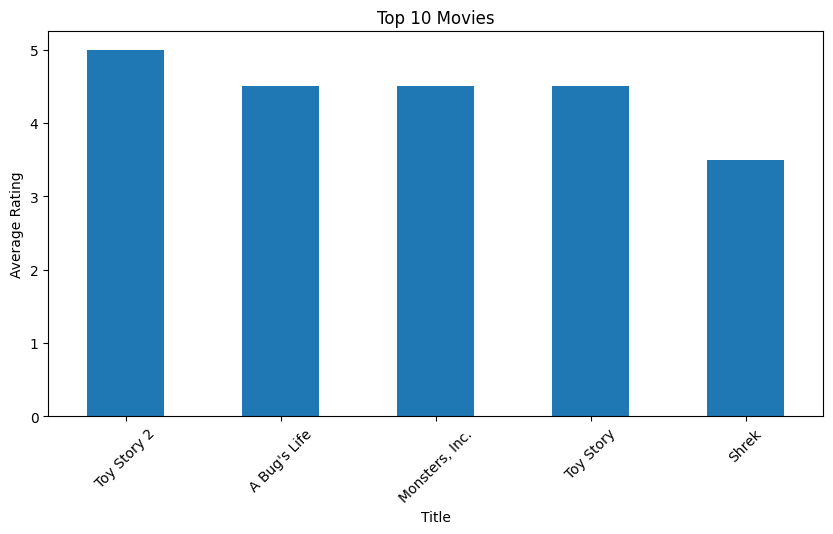

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top10.plot(kind="bar")
plt.title("Top 10 Movies")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()
